# PREGUNTA 11: Ejercicio Práctico 1 Análisis de estrategias de opciones con datos reales
# Eduardo Veytia Hernández

### Ejercicio Práctico 1: Análisis de estrategias de opciones con datos reales

### 1. Usando yfinance, descarga la cadena de opciones vigente de un activo de tu elección con opciones líquidas.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import warnings
from scipy.stats import norm
import datetime as dt
warnings.filterwarnings('ignore')

## Funciones auxiliares

In [2]:
def payoff_leg(S, tipo, K, prima, posicion):
    """Payoff de una sola pata al vencimiento."""
    if tipo == 'call':
        intrinseco = np.maximum(S - K, 0)
    else:
        intrinseco = np.maximum(K - S, 0)
    return posicion * (intrinseco - prima)

def payoff_estrategia(S_range, legs):
    """Suma el P&L de todas las patas sobre el rango de precios."""
    pnl = np.zeros_like(S_range, dtype=float)
    for leg in legs:
        pnl += payoff_leg(S_range, leg['tipo'], leg['K'], leg['prima'], leg['posicion'])
    return pnl

def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Grafica el payoff diagram con formato estándar."""
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, pnl, 'b-', linewidth=2, label='P&L al vencimiento')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    # línea vertical del precio actual
    if S0 is not None:
        plt.axvline(S0, color='red', linewidth=1.5, linestyle='--', label=f'S0 = {S0:.2f}')
    # líneas de strikes
    if K_lines:
        colors = ['green', 'orange', 'purple']
        for i, (k, lbl) in enumerate(K_lines):
            plt.axvline(k, color=colors[i % len(colors)], linewidth=1, linestyle=':', label=f'K = {lbl}')
    # zona de ganancia / pérdida
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    plt.title(titulo, fontsize=13)
    plt.xlabel('Precio del subyacente (ST)')
    plt.ylabel('P&L ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
def bs_greeks(S, K, T, r, sigma, tipo='call'):
    """Calcula las griegas individuales usando la fórmula de Black-Scholes."""
    # Evitar divisiones por cero si sigma o T son muy pequeños
    sigma = max(sigma, 0.0001)
    T = max(T, 0.0001)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100  # Dividido entre 100 para convención estándar (cambio de 1%)
    
    if tipo == 'call':
        delta = norm.cdf(d1)
        theta = (- (S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    elif tipo == 'put':
        delta = norm.cdf(d1) - 1
        theta = (- (S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        
    return delta, gamma, theta, vega

def get_iv(df, strike):
    """Devuelve la volatilidad implícita del strike solicitado."""
    row = df.loc[df['strike'] == strike, 'impliedVolatility']
    if row.empty:
        idx = (df['strike'] - strike).abs().idxmin()
        return float(df.loc[idx, 'impliedVolatility'])
    return float(row.iloc[0])

In [7]:
# --- precio spot ---
AAPL = yf.Ticker('AAPL')
S0 = AAPL.history(period='1d')['Close'].iloc[-1]
print(f'S0 (precio actual AAPL) : ${S0:.2f}')

# --- cadena de opciones para el vencimiento solicitado ---
EXP = '2026-05-18'
chain = AAPL.option_chain(EXP)

calls = chain.calls.copy()
puts  = chain.puts.copy()

# precio mid = (bid + ask) / 2
calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid']  = (puts['bid']  + puts['ask'])  / 2

# mostrar strikes cercanos a S0 para referencia
print('\nCalls cercanos a S0:')
print(calls[['strike','bid','ask','mid']].set_index('strike')
      .loc[S0*0.95:S0*1.05].round(2).to_string())

print('\nPuts cercanos a S0:')
print(puts[['strike','bid','ask','mid']].set_index('strike')
      .loc[S0*0.95:S0*1.05].round(2).to_string())

S0 (precio actual AAPL) : $294.80

Calls cercanos a S0:
          bid    ask    mid
strike                     
282.5   12.75  13.05  12.90
285.0   10.50  10.85  10.68
287.5    8.35   8.70   8.52
290.0    6.40   6.65   6.52
292.5    4.75   4.90   4.82
295.0    3.35   3.50   3.42
297.5    2.29   2.33   2.31
300.0    1.49   1.54   1.52
302.5    0.95   0.97   0.96
305.0    0.59   0.62   0.60
307.5    0.37   0.40   0.38

Puts cercanos a S0:
          bid    ask    mid
strike                     
282.5    0.40   0.42   0.41
285.0    0.62   0.66   0.64
287.5    0.96   1.02   0.99
290.0    1.50   1.58   1.54
292.5    2.28   2.37   2.33
295.0    3.30   3.50   3.40
297.5    4.70   5.00   4.85
300.0    6.30   6.70   6.50
302.5    8.25   8.65   8.45
307.5   12.75  13.15  12.95


### 2. Selecciona los contratos necesarios para construir dos de las siguientes estrategias (cada estudiante elige cuáles):
## **- Long straddle**
## **- Bull call spread**
- Bear put spread
- Iron condor
- Protective put

In [8]:
# --- selección de strikes y primas mid ---
# se elige el strike ATM más cercano para straddle

def get_mid(df, strike):
    """Devuelve el precio mid del strike solicitado."""
    row = df.loc[df['strike'] == strike, 'mid']
    if row.empty:
        # tomar el strike más cercano si no existe exacto
        idx = (df['strike'] - strike).abs().idxmin()
        return float(df.loc[idx, 'mid'])
    return float(row.iloc[0])

available_strikes = sorted(calls['strike'].unique())

# strike ATM (más cercano a S0)
K_atm = min(available_strikes, key=lambda k: abs(k - S0))

# strikes OTM para strangle (~3 % fuera del dinero)
K_call_otm = min(available_strikes, key=lambda k: abs(k - S0 * 1.03))
K_put_otm  = min(available_strikes, key=lambda k: abs(k - S0 * 0.97))

# strikes para bull call spread: ligeramente ITM y OTM
K_bull_low  = min(available_strikes, key=lambda k: abs(k - S0 * 0.985))
K_bull_high = K_call_otm

# strikes para bear put spread: ATM y OTM
K_bear_high = K_atm
K_bear_low  = min(available_strikes, key=lambda k: abs(k - S0 * 0.955))

print(f'Strike ATM          : {K_atm}')
print(f'Strangle call OTM   : {K_call_otm}')
print(f'Strangle put OTM    : {K_put_otm}')
print(f'Bull spread K1/K2   : {K_bull_low} / {K_bull_high}')
print(f'Bear spread K1/K2   : {K_bear_high} / {K_bear_low}')

# rango de precios para todas las gráficas
S_range = np.linspace(S0 * 0.80, S0 * 1.20, 500)

Strike ATM          : 295.0
Strangle call OTM   : 302.5
Strangle put OTM    : 285.0
Bull spread K1/K2   : 290.0 / 302.5
Bear spread K1/K2   : 295.0 / 282.5


### 3. Para cada estrategia: grafica el diagrama de payoff al vencimiento, e indica claramente el breakeven, la ganancia máxima y la pérdida máxima.


## Long Straddle

K (ATM)            : 295.0
Call mid           : $3.42
Put mid            : $3.40
Costo total        : $6.82
Break-even sup.    : $301.82
Break-even inf.    : $288.18
Pérdida máxima     : $-6.82  (si ST = 295.0 al vencimiento)


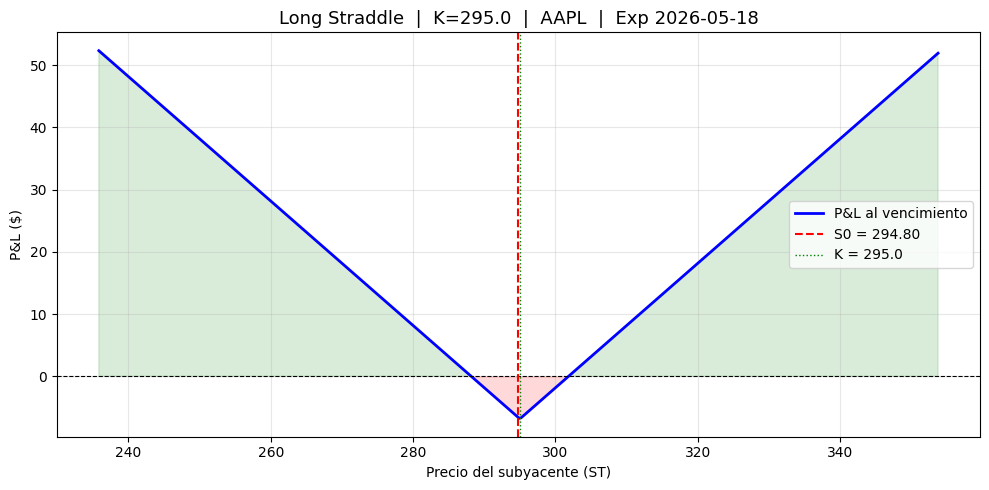

In [14]:
# --- primas mid reales ---
K = K_atm
C = get_mid(calls, K)
P = get_mid(puts,  K)

print(f'K (ATM)            : {K}')
print(f'Call mid           : ${C:.2f}')
print(f'Put mid            : ${P:.2f}')

legs_straddle = [
    {'tipo': 'call', 'K': K, 'prima': C, 'posicion': +1},
    {'tipo': 'put',  'K': K, 'prima': P, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_straddle)

print(f'Costo total        : ${C+P:.2f}')
print(f'Break-even sup.    : ${K+C+P:.2f}')
print(f'Break-even inf.    : ${K-C-P:.2f}')
print(f'Pérdida máxima     : ${-(C+P):.2f}  (si ST = {K} al vencimiento)')

graficar_estrategia(S_range, pnl,
                    f'Long Straddle  |  K={K}  |  AAPL  |  Exp {EXP}',
                    S0=S0, K_lines=[(K, f'{K}')])

## Bull Call Spread

K1 (buy call)      : 290.0  |  prima: $6.53
K2 (sell call)     : 302.5  |  prima: $0.96
Prima neta pagada  : $5.57
Ganancia máxima    : $6.93  (si ST ≥ 302.5)
Pérdida máxima     : $-5.57  (si ST ≤ 290.0)
Break-even         : $295.56


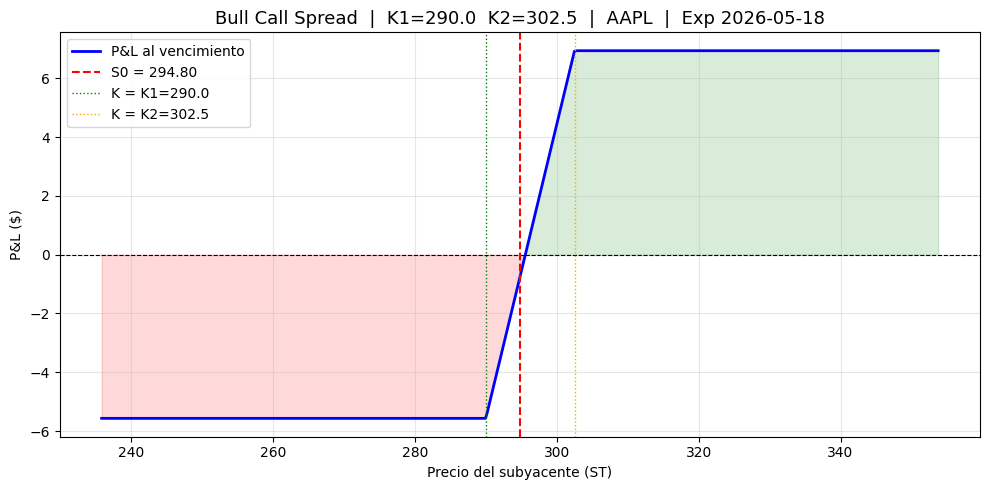

In [15]:
K1 = K_bull_low
K2 = K_bull_high
C1 = get_mid(calls, K1)
C2 = get_mid(calls, K2)

print(f'K1 (buy call)      : {K1}  |  prima: ${C1:.2f}')
print(f'K2 (sell call)     : {K2}  |  prima: ${C2:.2f}')

legs_bull = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -1},
]

pnl = payoff_estrategia(S_range, legs_bull)
prima_neta = C1 - C2

print(f'Prima neta pagada  : ${prima_neta:.2f}')
print(f'Ganancia máxima    : ${(K2-K1)-prima_neta:.2f}  (si ST ≥ {K2})')
print(f'Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≤ {K1})')
print(f'Break-even         : ${K1+prima_neta:.2f}')

graficar_estrategia(S_range, pnl,
                    f'Bull Call Spread  |  K1={K1}  K2={K2}  |  AAPL  |  Exp {EXP}',
                    S0=S0, K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}')])

## Tabla resumen

In [11]:
resumen = pd.DataFrame([
    {
        'Estrategia'     : 'Long Straddle',
        'Costo / Prima neta ($)': round(C + P, 2),
        'Ganancia máx.'  : 'Ilimitada',
        'Pérdida máx. ($)': round(-(C + P), 2),
        'Break-even(s)'  : f'{K-C-P:.2f}  /  {K+C+P:.2f}'
    },
    {
        'Estrategia'     : 'Bull Call Spread',
        'Costo / Prima neta ($)': round(prima_neta, 2),
        'Ganancia máx.'  : f'${(K2-K1)-prima_neta:.2f}',
        'Pérdida máx. ($)': round(-prima_neta, 2),
        'Break-even(s)'  : f'{K1+prima_neta:.2f}'
    }
])

print(resumen.to_string(index=False))

      Estrategia  Costo / Prima neta ($) Ganancia máx.  Pérdida máx. ($)     Break-even(s)
   Long Straddle                    6.82     Ilimitada             -6.82 288.18  /  301.82
Bull Call Spread                    5.57         $6.93             -5.57            295.56


### 4. Reporta las Griegas individuales de cada contrato usado (Delta, Gamma, Theta, Vega) tomándolas de la cadena de opciones o calculándolas con Black-Scholes. Calcula las Griegas netas del portafolio resultante de cada estrategia.

In [13]:
# --- Preparar parámetros (T y r) ---
# Tasa libre de riesgo aproximada (5%)
r = 0.05 

# Calcular T (tiempo al vencimiento en años)
hoy = dt.datetime.today()
try:
    fecha_exp = dt.datetime.strptime(EXP, '%Y-%m-%d')
    T = (fecha_exp - hoy).days / 365.0
    if T <= 0:  # Por si el contrato expira hoy o ya expiró en tu cadena
        T = 0.001
except:
    T = 30 / 365.0 # Fallback genérico a 30 días

# ---  Extraer volatilidades implícitas ---
iv_c_atm = get_iv(calls, K_atm)
iv_p_atm = get_iv(puts, K_atm)

iv_c1 = get_iv(calls, K1)
iv_c2 = get_iv(calls, K2)

# --- Calcular Griegas Individuales ---
# Straddle
d_c_atm, g_c_atm, t_c_atm, v_c_atm = bs_greeks(S0, K_atm, T, r, iv_c_atm, 'call')
d_p_atm, g_p_atm, t_p_atm, v_p_atm = bs_greeks(S0, K_atm, T, r, iv_p_atm, 'put')

# Bull Call Spread
d_c1, g_c1, t_c1, v_c1 = bs_greeks(S0, K1, T, r, iv_c1, 'call')
d_c2, g_c2, t_c2, v_c2 = bs_greeks(S0, K2, T, r, iv_c2, 'call')

# --- Calcular Griegas Netas ---
# Long Straddle (Comprar Call + Comprar Put)
net_delta_straddle = d_c_atm + d_p_atm
net_gamma_straddle = g_c_atm + g_p_atm
net_theta_straddle = t_c_atm + t_p_atm
net_vega_straddle = v_c_atm + v_p_atm

# Bull Call Spread (Comprar Call K1 + Vender Call K2)
net_delta_bull = d_c1 - d_c2
net_gamma_bull = g_c1 - g_c2
net_theta_bull = t_c1 - t_c2
net_vega_bull = v_c1 - v_c2

# --- Mostrar Tabla Resumen ---
griegas_resumen = pd.DataFrame([
    {
        'Estrategia': 'Long Straddle',
        'Delta': round(net_delta_straddle, 4),
        'Gamma': round(net_gamma_straddle, 4),
        'Theta': round(net_theta_straddle, 4),
        'Vega': round(net_vega_straddle, 4)
    },
    {
        'Estrategia': 'Bull Call Spread',
        'Delta': round(net_delta_bull, 4),
        'Gamma': round(net_gamma_bull, 4),
        'Theta': round(net_theta_bull, 4),
        'Vega': round(net_vega_bull, 4)
    }
])

print("\n--- Griegas Netas del Portafolio ---")
print(griegas_resumen.to_string(index=False))


--- Griegas Netas del Portafolio ---
      Estrategia  Delta  Gamma   Theta   Vega
   Long Straddle 0.0110 0.0997 -0.6382 0.2753
Bull Call Spread 0.5402 0.0055 -0.0977 0.0238


### 5. En markdown: explica en qué condición de mercado (dirección esperada y nivel de volatilidad) tiene sentido cada estrategia construida. Vincula explícitamente tu respuesta con el signo e interpretación de al menos dos Griegas netas calculadas.

**1. Long Straddle (AAPL, K=295.0)**

**Condición de mercado esperada:** Esta estrategia se usa cuando se anticipa un aumento drástico en la volatilidad o un movimiento violento en el precio del activo subyacente.

**- Interpretación de las Griegas netas calculadas:**

- **Vega (+0.2753):**

La estrategia es larga en volatilidad. El valor de la posición aumentará si la volatilidad implícita del mercado sube.

- **Gamma (+0.0997):** 

La posición goza de un Gamma positivo. Esto significa que a medida que el precio de AAPL realiza movimientos grandes, el Delta de la posición se ajustará a nuestro favor de manera acelerada.

**2. Bull Call Spread (AAPL, K1=290.0, K2=302.5)**

**Condición de mercado esperada:** Se usa ante una perspectiva moderadamente alcista. Tiene sentido cuando se espera que el activo suba, pero se desea reducir el costo de entrada ($5.57) vendiendo un Call de strike superior, a cambio de topar la ganancia máxima ($6.93).

**Interpretación de las Griegas netas calculadas:**

**Delta (+0.5402):** 

La posición tiene un sesgo direccional muy alcista. El Delta positivo indica que el valor del portafolio se beneficiará si el precio de AAPL suba hacia el strike (K2).

**Vega (+0.0238):** 

La exposición a cambios en la volatilidad está casi neutralizada. Al comprar una opción (K1) y vender otra (K2), los valores de Vega se cancelan mutuamente. Esto protege la posición contra el colapso de la volatilidad implícita.